# **Project Name** - EDA On Super Marker Sales

##### **Project Type**    - EDA
##### **Contribution**    - Individual
##### **Name** - Aryan Ranjan
##### **Section** - D2512
##### **Roll Number** A-12
##### **Reg. Number** - 12525291


# **Project Summary -**

This Exploratory Data Analysis (EDA) project focuses on analyzing sales transaction data to uncover meaningful business insights. The dataset was cleaned by handling missing values and removing outliers to ensure accuracy. Various visualizations such as histograms, boxplots, bar charts, pie charts, and heatmaps were used to understand patterns in revenue, customer behavior, product performance, and time-based trends. The analysis also compares different segments like branches, cities, gender, and quantity levels to identify key factors influencing sales performance.

# **GitHub Link -**

https://github.com/aryan-r03/CapStone--EDA--SuperMarket_Sales

# **Problem Statement**


`Problem Statement - 1 :`
Detect and remove outliers in sales revenue using IQR and visualize the results using boxplots.

`Problem Statement - 2 :`
To explore and analyze the distribution of sales revenue by handling missing values using mean imputation and visualizing the data using histogram and boxplot. The goal is to understand data patterns, variability, and detect potential outliers.


`Problem Statement - 3 :`
To evaluate the performance of different product categories by aggregating total sales revenue and representing it through a bar chart. Furthermore, to analyze the proportion of each category in the dataset using a pie chart for better understanding of category distribution.


`Problem Statement - 4 :`
To evaluate and compare the performance of different branches by analyzing total revenue, average transaction value, and customer footfall using grouped visualizations. The objective is to identify the most profitable and operationally efficient branch.


`Problem Statement - 5 :`
To study the distribution of payment methods used by customers and assess their impact on total revenue and average transaction value. Use a pie chart for payment method share and a bar chart for revenue contribution per method.


`Problem Statement - 6 :`
To identify peak shopping hours by extracting the hour from the time column and aggregating transaction count and revenue. Visualize hourly trends using a line chart and a day-vs-hour heatmap to uncover high-activity time windows for operational and marketing decisions.


`Problem Statement - 7 :`
Compare spending patterns between male and female customers across different product lines to uncover category-specific preferences.

`Problem Statement - 8 :`
Compare revenue trends, preferred product lines, and customer types across different cities to guide regional strategy.

`Problem Statement - 9 :`
Compare transactions with high quantity vs low quantity in terms of revenue efficiency and product mix.


`Problem Statement - 9 :`
To build and evaluate a regression model that predicts sales revenue using features such as unit price, quantity, and customer rating, with the objective of understanding key drivers of revenue and assessing model performance.


`Problem Statement - 10 :`
Analyze the interrelationship between numerical features such as unit cost, quantity, customer rating, and revenue to identify key patterns influencing sales performance.

# ***Let's Begin !***

In [ ]:
# Importing all the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as grd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

In [ ]:
# Data Loading
data_raw = pd.read_csv("/content/supermarket_sales.csv")

In [ ]:
# Viewing the dataset - top 5 entries
data_raw.head()

,invoice_id,branch,city,customer_type,gender_customer,product_line,unit_cost,quantity,5pct_markup,revenue,date,time,payment_method,cogs,gm_pct,gross_income,rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,01/05/19,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,03/08/19,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,03/03/19,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,02/08/19,10:37,Ewallet,604.17,4.761905,30.2085,5.3


In [ ]:
# Checking the null values in the dataset
data_raw.isnull().sum()

,0
invoice_id,0
branch,0
city,0
customer_type,0
gender_customer,0
product_line,0
unit_cost,0
quantity,0
5pct_markup,0
revenue,0


In [ ]:
# Checaking the duplicated values in the dataset
data_raw.duplicated().sum()

np.int64(0)

In [ ]:
data_raw.columns

Index(['invoice_id', 'branch', 'city', 'customer_type', 'gender_customer',
       'product_line', 'unit_cost', 'quantity', '5pct_markup', 'revenue',
       'date', 'time', 'payment_method', 'cogs', 'gm_pct', 'gross_income',
       'rating'],
      dtype='object')

In [ ]:
# Viewing the columns of the dataset
data_raw.columns.tolist()

['invoice_id',
 'branch',
 'city',
 'customer_type',
 'gender_customer',
 'product_line',
 'unit_cost',
 'quantity',
 '5pct_markup',
 'revenue',
 'date',
 'time',
 'payment_method',
 'cogs',
 'gm_pct',
 'gross_income',
 'rating']

In [ ]:
data_raw

,invoice_id,branch,city,customer_type,gender_customer,product_line,unit_cost,quantity,5pct_markup,revenue,date,time,payment_method,cogs,gm_pct,gross_income,rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,01/05/19,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,03/08/19,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,03/03/19,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,02/08/19,10:37,Ewallet,604.17,4.761905,30.2085,5.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,233-67-5758,C,Naypyitaw,Normal,Male,Health and beauty,40.35,1,2.0175,42.3675,1/29/2019,13:46,Ewallet,40.35,4.761905,2.0175,6.2
996,303-96-2227,B,Mandalay,Normal,Female,Home and lifestyle,97.38,10,48.6900,1022.4900,03/02/19,17:16,Ewallet,973.80,4.761905,48.6900,4.4
997,727-02-1313,A,Yangon,Member,Male,Food and beverages,31.84,1,1.5920,33.4320,02/09/19,13:22,Cash,31.84,4.761905,1.5920,7.7
998,347-56-2442,A,Yangon,Normal,Male,Home and lifestyle,65.82,1,3.2910,69.1110,2/22/2019,15:33,Cash,65.82,4.761905,3.2910,4.1


In [ ]:
# Getting the description of the dataset
data_raw.describe()

,unit_cost,quantity,5pct_markup,revenue,cogs,gm_pct,gross_income,rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1.000000e+03,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,307.58738,4.761905e+00,15.379369,6.97270
std,26.494628,2.923431,11.708825,245.885335,234.17651,6.131498e-14,11.708825,1.71858
min,10.080000,1.000000,0.508500,10.678500,10.17000,4.761905e+00,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,118.49750,4.761905e+00,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,241.76000,4.761905e+00,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,448.90500,4.761905e+00,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,993.00000,4.761905e+00,49.650000,10.00000


In [ ]:
# Getting the data type of all the column of the dataset
data_raw.dtypes

,0
invoice_id,object
branch,object
city,object
customer_type,object
gender_customer,object
product_line,object
unit_cost,float64
quantity,int64
5pct_markup,float64
revenue,float64


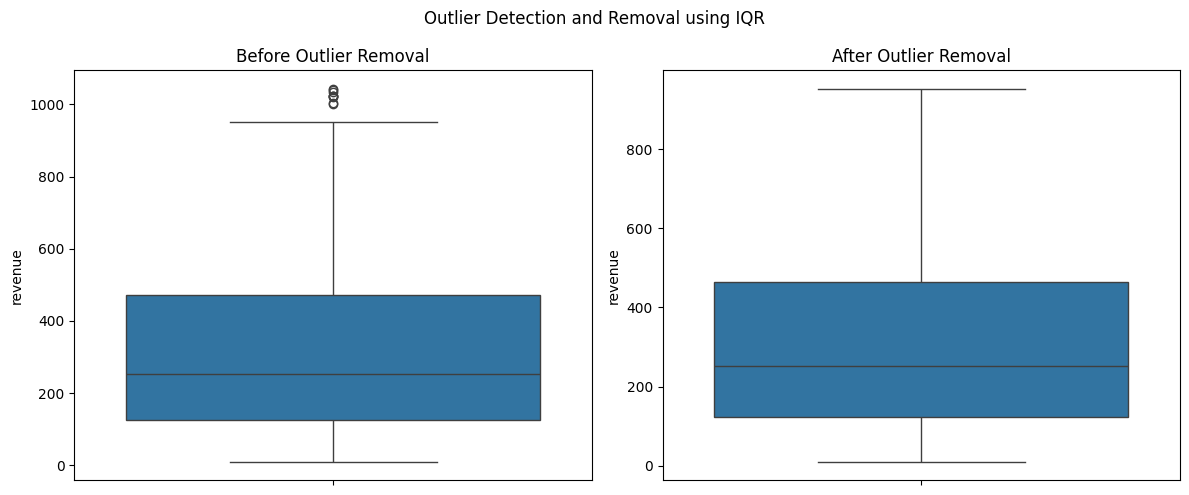

In [ ]:
# Problem Statement:
# Detect and remove outliers in sales revenue using IQR and visualize the results using boxplots.


# Select Column (Revenue)
col = 'revenue'

# IQR Method for Outliers
Q1 = data_raw[col].quantile(0.25)
Q3 = data_raw[col].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Removing outliers
data = data_raw[(data_raw[col] > lower) & (data_raw[col] < upper)]

plt.figure(figsize = (12, 5))

# Before Outliers
plt.subplot(1, 2, 1)
sns.boxplot(y = data_raw[col])
plt.title("Before Outlier Removal")

# After Outliers
plt.subplot(1, 2, 2)
sns.boxplot(y = data[col])
plt.title("After Outlier Removal")
plt.suptitle("Outlier Detection and Removal using IQR")
plt.tight_layout()
plt.show()

------------------------------
Missing Values:
invoice_id         0
branch             0
city               0
customer_type      0
gender_customer    0
product_line       0
unit_cost          0
quantity           0
5pct_markup        0
revenue            0
date               0
time               0
payment_method     0
cogs               0
gm_pct             0
gross_income       0
rating             0
dtype: int64
------------------------------
Original Size: 991
After Outlier Removal: 991


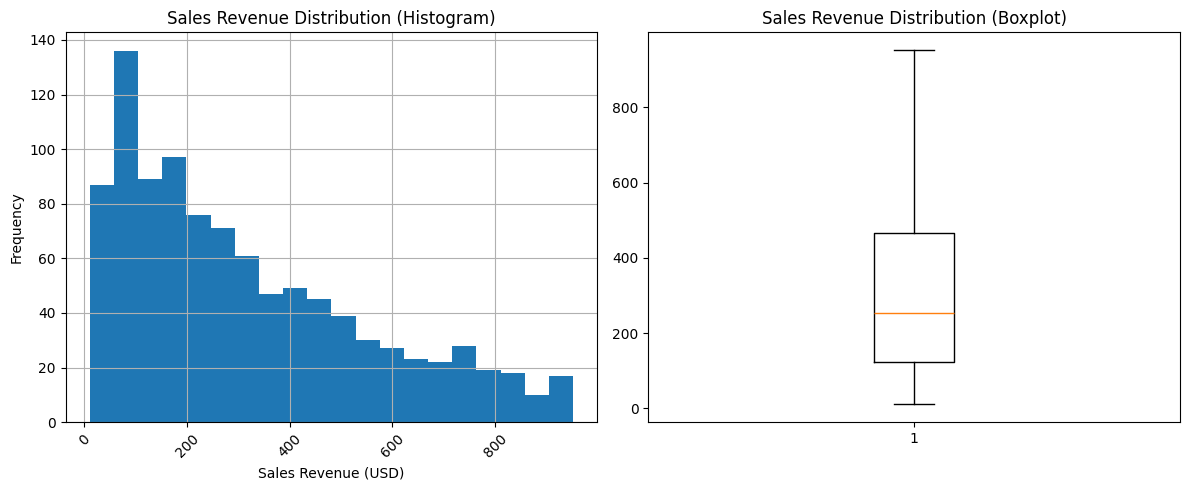

In [ ]:
# Problem Statement:
# To explore and analyze the distribution of sales revenue by handling missing values
# using mean imputation and visualizing the data using histogram and boxplot.
# The goal is to understand data patterns, variability, and detect potential outliers.

# Select Column (Revenue)

rev = data[['revenue']]
print("---" * 10)
print(f"Missing Values:\n{data.isnull().sum()}")
print("---" * 10)

# Fill missing values with mean
rev = rev.fillna(data.mean(numeric_only = True))

# IQR Outlier Detection
Q1 = rev['revenue'].quantile(0.25)
Q3 = rev['revenue'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Remove outliers
rev_clean = rev[(rev['revenue'] >= lower) & (rev['revenue'] <= upper)]

print(f"Original Size: {len(rev)}")
print(f"After Outlier Removal: {len(rev_clean)}")

# Visualization
plt.figure(figsize = (12, 5))

# Histogram
plt.subplot(1, 2, 1)
plt.hist(rev['revenue'], bins = 20)
plt.title("Sales Revenue Distribution (Histogram)")
plt.xlabel("Sales Revenue (USD)")
plt.ylabel("Frequency")
plt.xticks(rotation = 45)
plt.grid()

# Boxplot
plt.subplot(1, 2, 2)
plt.boxplot(rev['revenue'])
plt.title("Sales Revenue Distribution (Boxplot)")

plt.tight_layout()
plt.show()

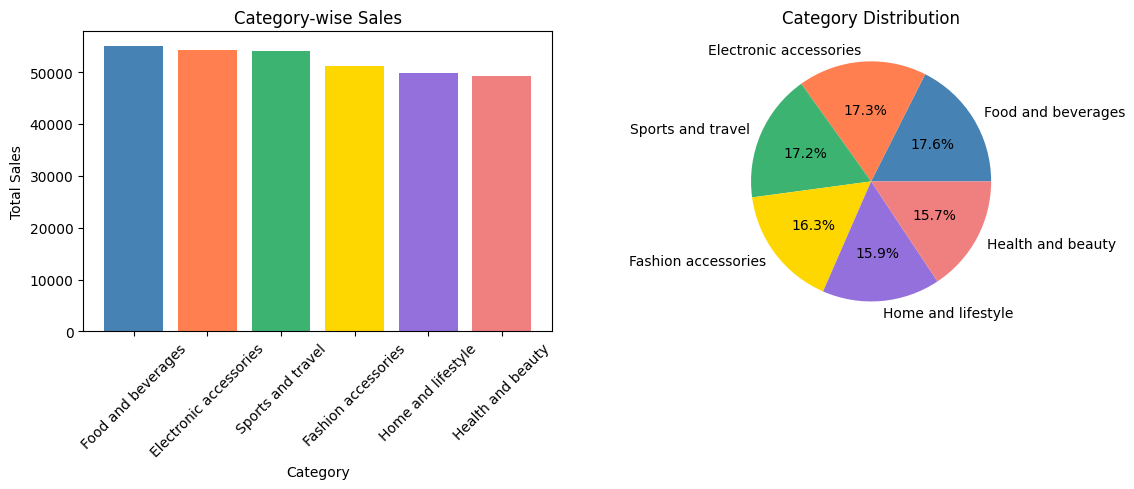

In [ ]:
# Problem Statement:
# To evaluate the performance of different product categories by aggregating
# total sales revenue and representing it through a bar chart. Furthermore,
# to analyze the proportion of each category in the dataset using a pie chart
# for better understanding of category distribution.

# Revenue by Sales in Category
category_sales = data.groupby('product_line')['revenue'].sum().sort_values(ascending = False)

# Choosing Colours
colors = ['steelblue','coral','mediumseagreen','gold','mediumpurple','lightcoral']

# Create Subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Category-wise Sales
ax1.bar(category_sales.index, category_sales.values, color=colors)
ax1.set(title = "Category-wise Sales", xlabel = "Category", ylabel = "Total Sales")
ax1.tick_params(axis = 'x', rotation = 45)

# Category Distribution
ax2.pie(category_sales, labels = category_sales.index, autopct = '%1.1f%%', colors = colors)
ax2.set_title("Category Distribution")

plt.tight_layout()
plt.show()

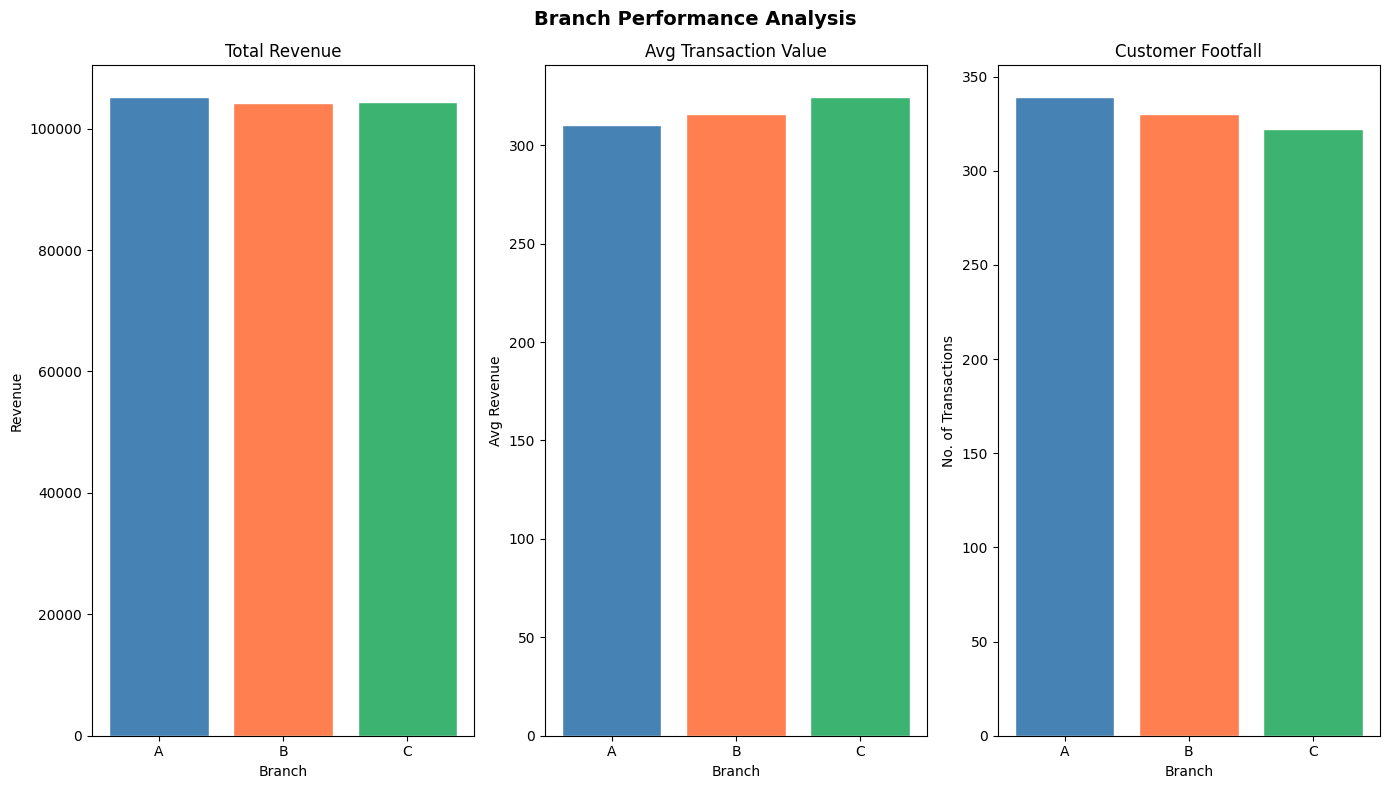

In [ ]:
# Problem Statement:
# To evaluate and compare the performance of different branches by analyzing
# total revenue, average transaction value, and customer footfall using grouped visualizations.
#  The objective is to identify the most profitable and operationally efficient branch.

# Revenue by Sales in Brances
branch = data.groupby('branch')['revenue'].agg(['sum', 'mean', 'count'])

# Choosing Colours
colors = ['steelblue', 'coral', 'mediumseagreen']

# Create Subplots
fig, axes = plt.subplots(1, 3, figsize=(14, 8))

# Visualization
for ax, col, title, ylabel in zip(axes,
    ['sum', 'mean', 'count'],
    ['Total Revenue', 'Avg Transaction Value', 'Customer Footfall'],
    ['Revenue', 'Avg Revenue', 'No. of Transactions']):
    ax.bar(branch.index, branch[col], color = colors, edgecolor = 'white')
    ax.set(title = title, xlabel = "Branch", ylabel = ylabel)

plt.suptitle("Branch Performance Analysis", fontsize = 14, fontweight = 'bold')
plt.tight_layout()
plt.show()

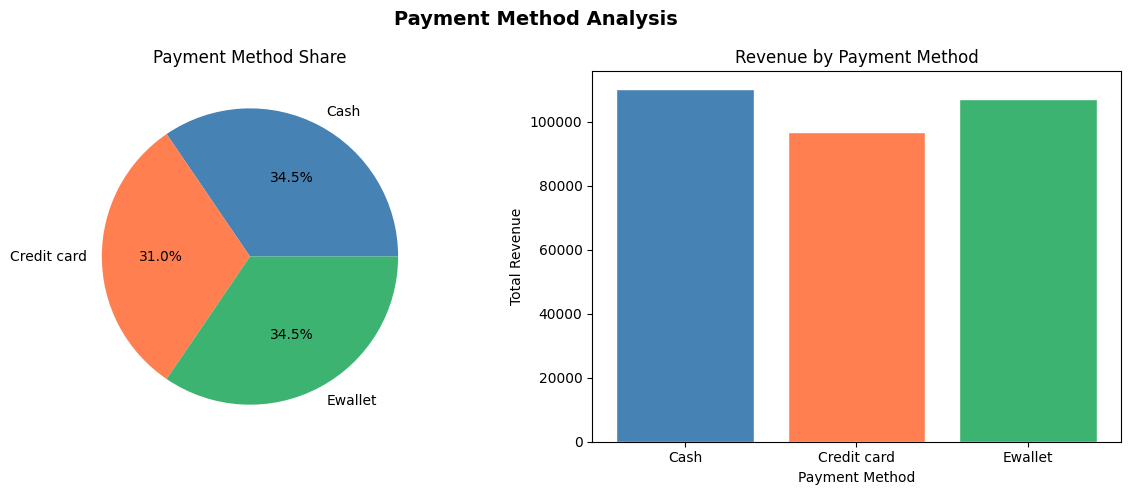

In [ ]:
# Problem Statement:
# To study the distribution of payment methods used by customers and assess
# their impact on total revenue and average transaction value. Use a pie chart
# for payment method share and a bar chart for revenue contribution per method.

# Revenue by Payement
payment = data.groupby('payment_method')['revenue'].agg(['count', 'sum'])

# Choosing Colours
colors  = ['steelblue', 'coral', 'mediumseagreen']

# Create Subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (12, 5))

# Payment Method Share
ax1.pie(payment['count'], labels = payment.index, autopct = '%1.1f%%', colors = colors)
ax1.set_title("Payment Method Share")

# Payment Method Analysis
ax2.bar(payment.index, payment['sum'], color = colors, edgecolor = 'white')
ax2.set(title = "Revenue by Payment Method", xlabel = "Payment Method", ylabel = "Total Revenue")

plt.suptitle("Payment Method Analysis", fontsize = 14, fontweight = 'bold')
plt.tight_layout()
plt.show()

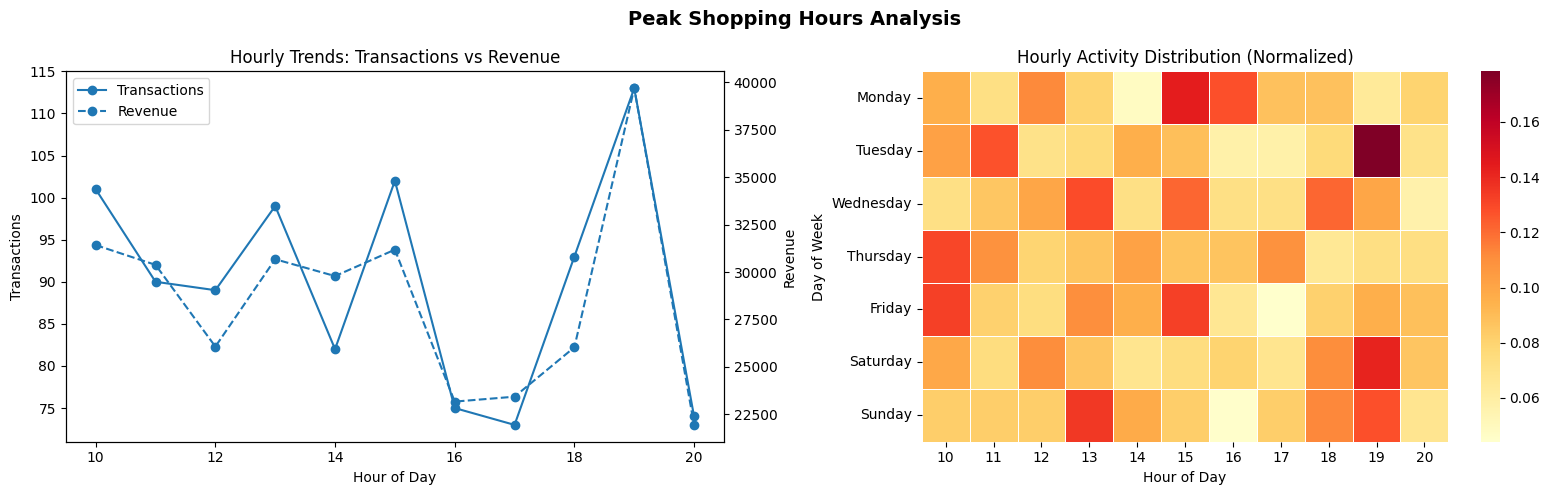

In [ ]:
# Problem Statement:
# To identify peak shopping hours by extracting the hour from the time column
# and aggregating transaction count and revenue. Visualize hourly trends using
# a line chart and a day-vs-hour heatmap to uncover high-activity time windows
# for operational and marketing decisions.

data = data.copy()

# Safe Feature Engineering
dt_time = pd.to_datetime(data['time'], format = 'mixed')
dt_date = pd.to_datetime(data['date'], format = 'mixed')

data.loc[:, 'hour'] = dt_time.dt.hour
data.loc[:, 'day']  = dt_date.dt.day_name()

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Aggregation
hourly = data.groupby('hour').agg(
    transactions = ('invoice_id', 'count'),
    revenue = ('revenue', 'sum')
)

# Pivot for Heatmap
pivot = data.groupby(['day', 'hour'])['invoice_id'].count().unstack()

# Reorder days
pivot = pivot.reindex(day_order)

# normalize (percentage per day for better insight)
pivot_pct = pivot.div(pivot.sum(axis = 1), axis = 0)

# Creating Subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (16, 5))

# Line Chart
ax1.plot(hourly.index, hourly['transactions'], marker = 'o', label = 'Transactions')
ax1.set_xlabel("Hour of Day")
ax1.set_ylabel("Transactions")

ax1_2 = ax1.twinx()
ax1_2.plot(hourly.index, hourly['revenue'], marker = 'o', linestyle = '--', label = 'Revenue')
ax1_2.set_ylabel("Revenue")
ax1.set_title("Hourly Trends: Transactions vs Revenue")

# Combine legends
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2)

# Heatmap (normalized = insight-driven)
sns.heatmap(pivot_pct, cmap = 'YlOrRd', ax = ax2, linewidths = 0.5)

ax2.set_title("Hourly Activity Distribution (Normalized)")
ax2.set_xlabel("Hour of Day")
ax2.set_ylabel("Day of Week")

plt.suptitle("Peak Shopping Hours Analysis", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

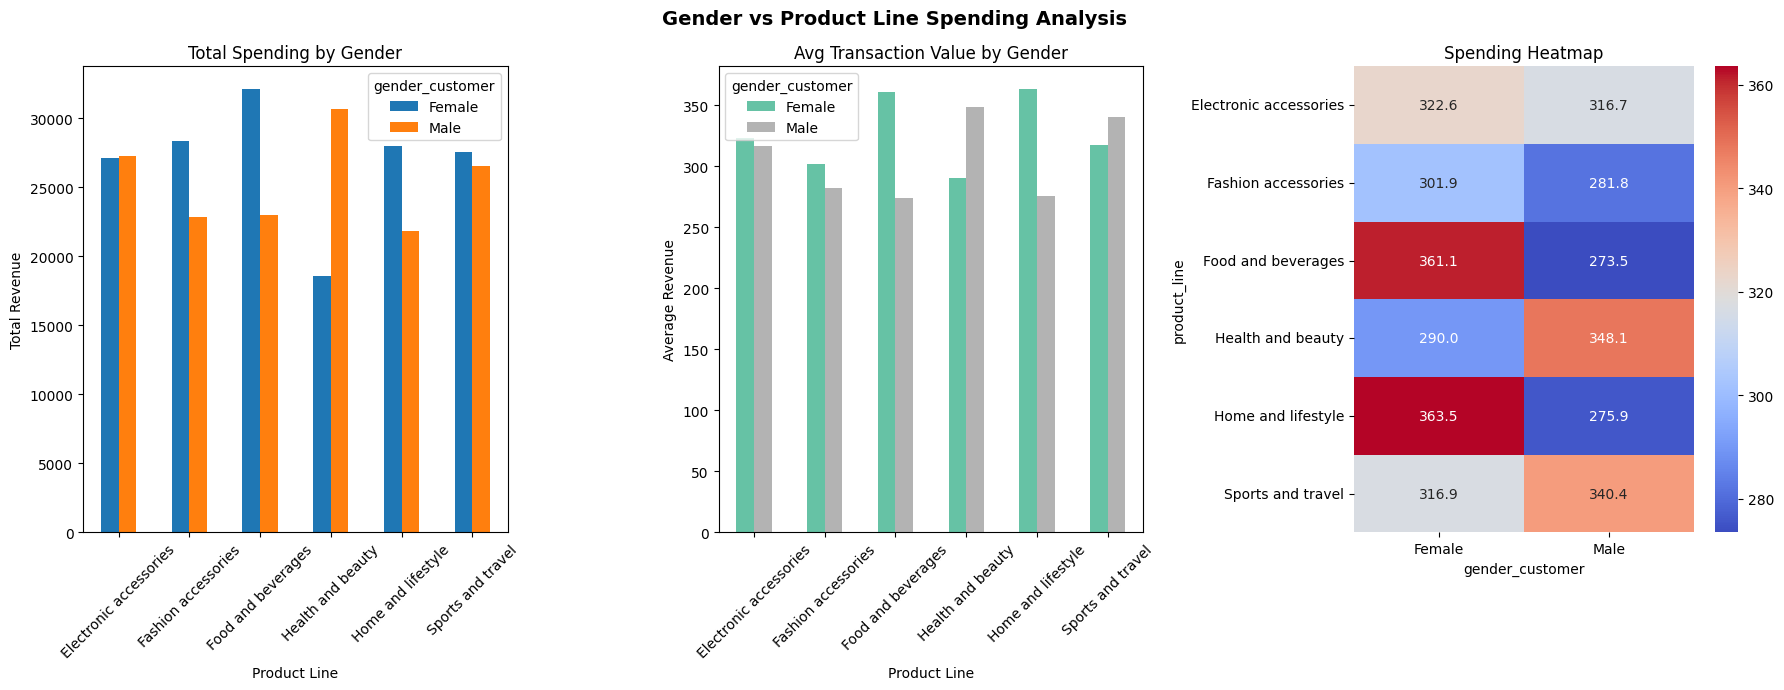

In [ ]:
# Problem Statement:
# Compare spending patterns between male and female customers
# across different product lines to uncover category-specific preferences.

# Formatting Gender of Customers
gender_product = data.groupby(['gender_customer', 'product_line'])['revenue'].agg(['sum', 'mean']).reset_index()
pivot_sum = gender_product.pivot(index = 'product_line', columns = 'gender_customer', values = 'sum')
pivot_mean = gender_product.pivot(index = 'product_line', columns = 'gender_customer', values = 'mean')

# Create Subplots
fig, axes = plt.subplots(1, 3, figsize = (18, 7))

# Total Spending
pivot_sum.plot(kind = 'bar', ax = axes[0])
axes[0].set_title("Total Spending by Gender")
axes[0].set_xlabel("Product Line")
axes[0].set_ylabel("Total Revenue")
axes[0].tick_params(axis = 'x', rotation = 45)

# Average Spending
pivot_mean.plot(kind = 'bar', ax = axes[1], colormap = 'Set2')
axes[1].set_title("Avg Transaction Value by Gender")
axes[1].set_xlabel("Product Line")
axes[1].set_ylabel("Average Revenue")
axes[1].tick_params(axis = 'x', rotation = 45)

# Heatmap Plotting
sns.heatmap(pivot_mean, annot = True, fmt = ".1f", cmap = "coolwarm", ax = axes[2])
axes[2].set_title("Spending Heatmap")

plt.suptitle("Gender vs Product Line Spending Analysis", fontsize = 14, fontweight = 'bold')
plt.tight_layout()
plt.show()

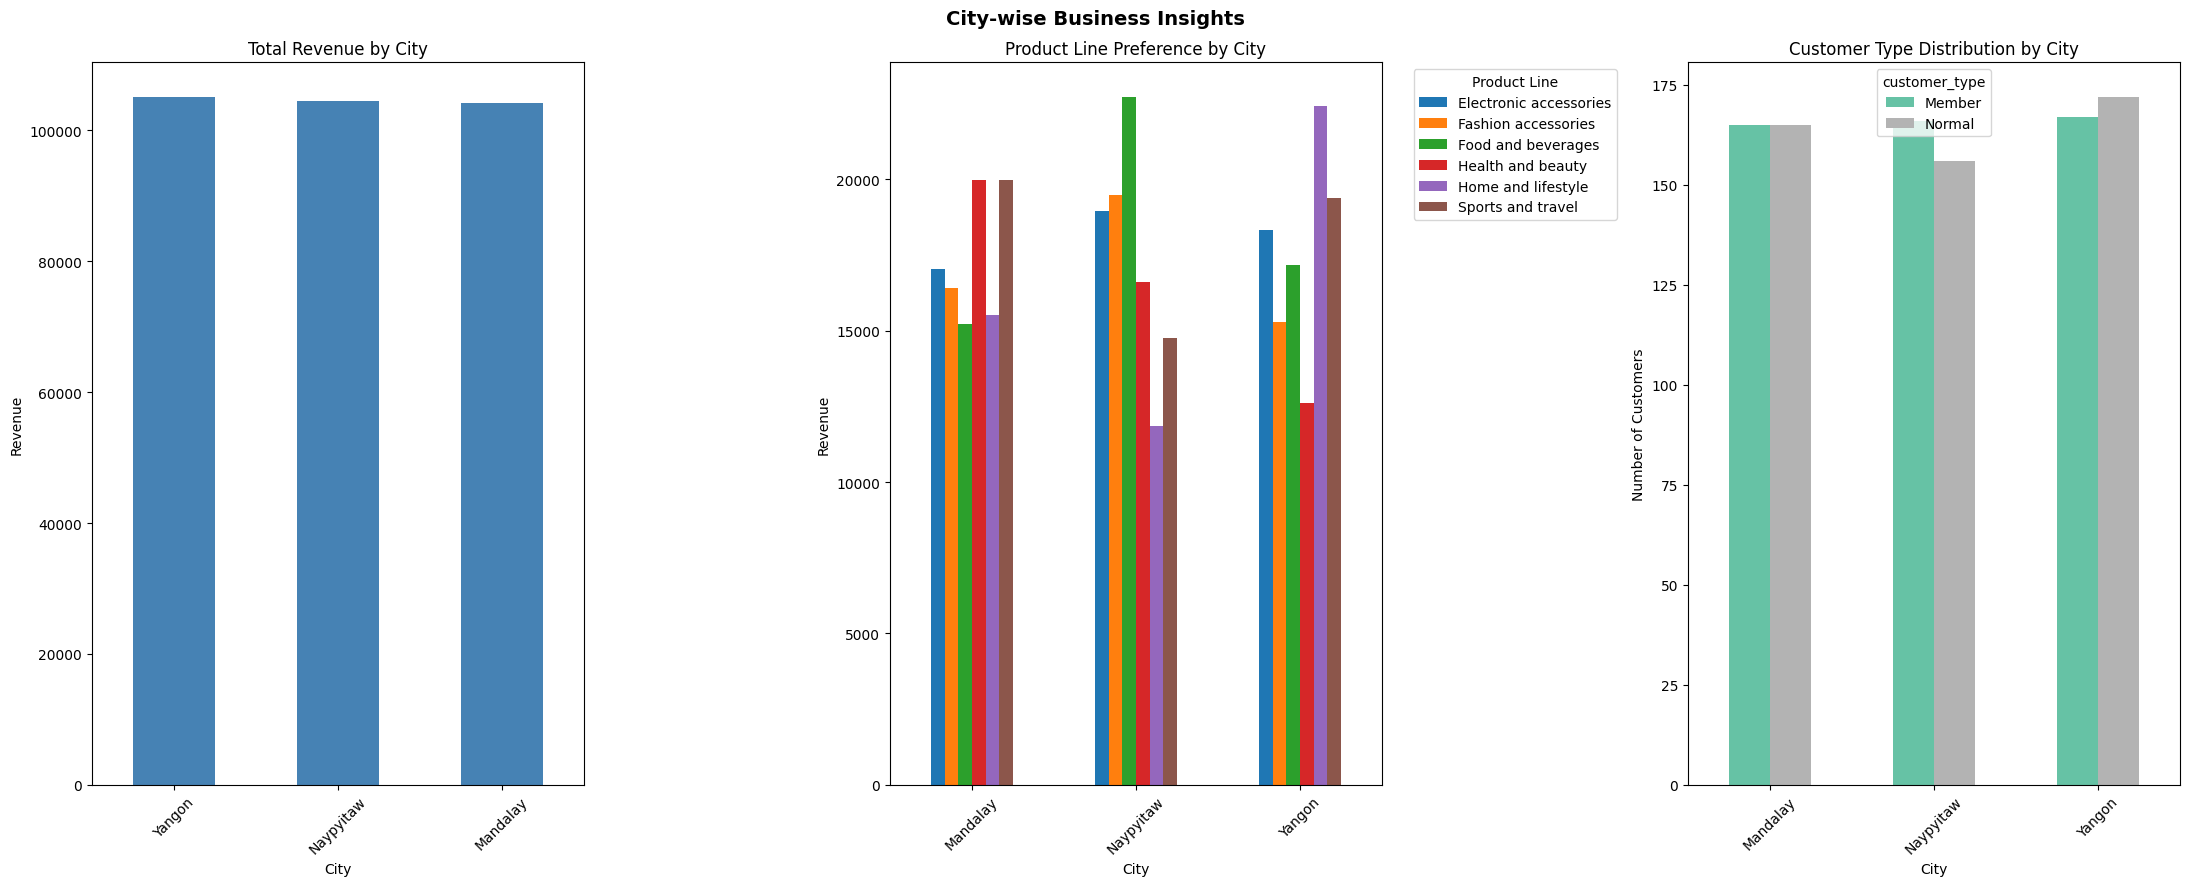

In [ ]:
# Problem Statement:
# Compare revenue trends, preferred product lines, and customer types
# across different cities to guide regional strategy.

# Revenue by City
city_revenue = data.groupby('city')['revenue'].sum().sort_values(ascending = False)

# Product Line Preference by City
city_product = data.groupby(['city', 'product_line'])['revenue'].sum().unstack()

# Customer Type Distribution by City
city_customer = data.groupby(['city', 'customer_type'])['invoice_id'].count().unstack()

# Create Subplots
fig, axes = plt.subplots(1, 3, figsize = (22, 9))

# Revenue by City
city_revenue.plot(kind = 'bar', ax = axes[0], color = 'steelblue')
axes[0].set_title("Total Revenue by City")
axes[0].set_xlabel("City")
axes[0].set_ylabel("Revenue")
axes[0].tick_params(axis = 'x', rotation = 45)

# Product Preference
city_product.plot(kind = 'bar', ax = axes[1])
axes[1].set_title("Product Line Preference by City")
axes[1].set_xlabel("City")
axes[1].set_ylabel("Revenue")
axes[1].tick_params(axis = 'x', rotation = 45)
axes[1].legend(title = "Product Line", bbox_to_anchor = (1.05, 1))

# Customer Type Distribution
city_customer.plot(kind = 'bar', ax = axes[2], colormap = 'Set2')
axes[2].set_title("Customer Type Distribution by City")
axes[2].set_xlabel("City")
axes[2].set_ylabel("Number of Customers")
axes[2].tick_params(axis = 'x', rotation = 45)

plt.suptitle("City-wise Business Insights", fontsize = 14, fontweight = 'bold')
plt.tight_layout()
plt.show()

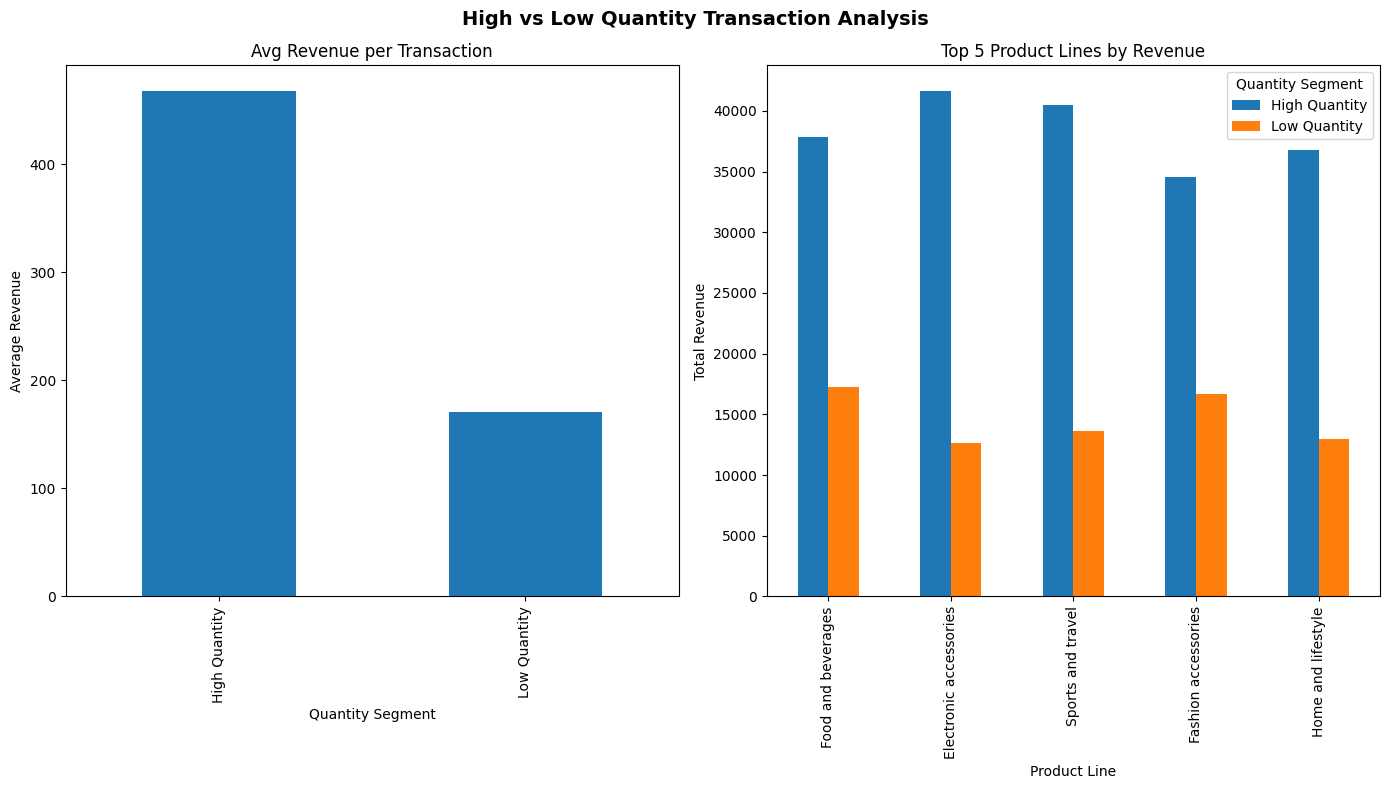

In [ ]:
# Problem Statement:
# Compare transactions with high quantity vs low quantity
#  in terms of revenue efficiency and product mix.

data = data.copy()

# Quantity Segmentation
threshold = data['quantity'].median()

data['quantity_segment'] = np.where(
    data['quantity'] > threshold,
    'High Quantity',
    'Low Quantity'
)

# Revenue Efficiency
efficiency = data.groupby('quantity_segment')['revenue'].agg(['mean', 'sum', 'count'])

# Product Mix
product_mix = data.groupby(['product_line', 'quantity_segment'])['revenue'].sum().unstack()

# Top 5 Products
top_products = product_mix.sum(axis = 1).sort_values(ascending = False).head(5).index
product_mix_top = product_mix.loc[top_products]

# Plotting
fig, axes = plt.subplots(1, 2, figsize = (14, 8))

# Revenue Efficiency
efficiency['mean'].plot(kind = 'bar', ax = axes[0])
axes[0].set_title("Avg Revenue per Transaction")
axes[0].set_xlabel("Quantity Segment")
axes[0].set_ylabel("Average Revenue")

# Product Comparison
product_mix_top.plot(kind = 'bar', ax = axes[1])
axes[1].set_title("Top 5 Product Lines by Revenue")
axes[1].set_xlabel("Product Line")
axes[1].set_ylabel("Total Revenue")
axes[1].legend(title="Quantity Segment")

plt.suptitle("High vs Low Quantity Transaction Analysis", fontsize = 14, fontweight = 'bold')
plt.tight_layout()
plt.show()

R² Score : 0.9031
RMSE : 79.0177


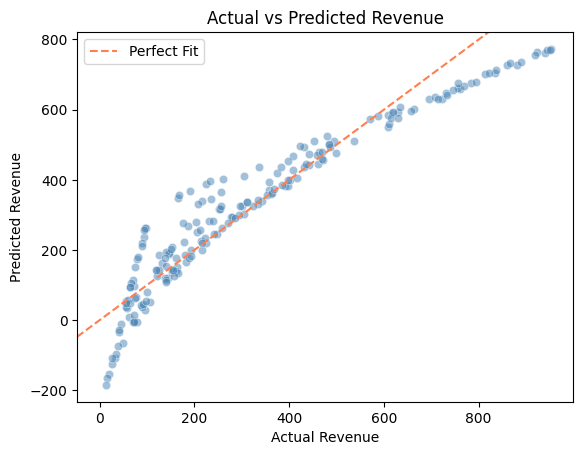

In [ ]:
# Problem Statement:
# To build and evaluate a regression model that predicts sales revenue using features
# such as unit price, quantity, and customer rating, with the objective of
# understanding key drivers of revenue and assessing model performance.


# Selecting independent variables (features)
X = data[['unit_cost', 'quantity', 'rating']]

# Target variable (what we want to predict)
y = data['revenue']

# Splitting data into training (80%) and testing (20%)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

# Model Training
from sklearn.linear_model import LinearRegression
model = LinearRegression().fit(X_train, y_train)

# Predicting revenue on unseen test data
y_pred = model.predict(X_test)

# Model Evaluation
from sklearn.metrics import mean_squared_error, r2_score

# R² Score
print(f"R² Score : {r2_score(y_test, y_pred):.4f}")
print(f"RMSE : {(mean_squared_error(y_test, y_pred)) ** 0.5:.4f}")

# Scatter plot comparing actual vs predicted values
sns.scatterplot(x = y_test, y = y_pred, alpha = 0.5, color = 'steelblue')

# Reference line (perfect prediction line: y = x)
plt.axline((0, 0), slope = 1, color = 'coral', linestyle = '--', label = 'Perfect Fit')

# Labels and title
plt.title("Actual vs Predicted Revenue")
plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")
plt.legend()

plt.show()

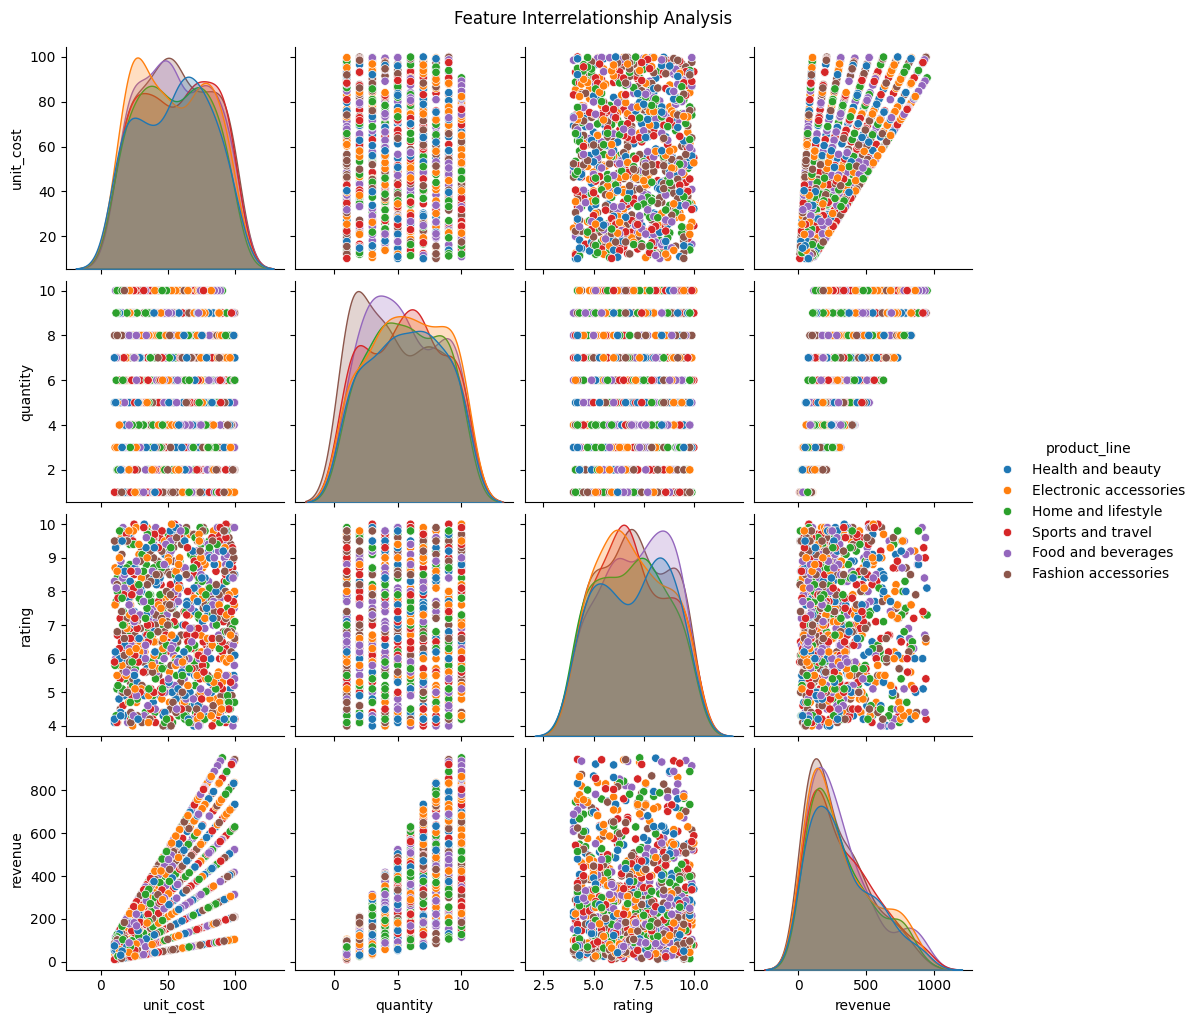

In [ ]:
# Problem Statement:
# Analyze the interrelationship between numerical features such as
# unit cost, quantity, customer rating, and revenue
# to identify key patterns influencing sales performance.

# Core features
cols = ['unit_cost', 'quantity', 'rating', 'revenue']

# Pair plot with segmentation
sns.pairplot(data[cols + ['product_line']], hue = 'product_line', diag_kind = 'kde')

plt.suptitle("Feature Interrelationship Analysis", y = 1.02)
plt.show()

# **Conclusion**

Sales performance is influenced by product categories, customer segments, and transaction patterns. Regional differences exist across branches and cities. High-quantity transactions boost revenue but vary in efficiency, while peak hours reveal key customer activity trends. These insights support better decisions in pricing, inventory, and marketing to improve profitability.